In [4]:
import pandas as pd

# Load the CSV file into a DataFrame
ball_by_ball_data = pd.read_csv('./ipl-dataset-2008-to-2025/ball_by_ball_data.csv')
ipl_matches_data = pd.read_csv('./ipl-dataset-2008-to-2025/ipl_matches_data.csv')
players_data = pd.read_csv('./ipl-dataset-2008-to-2025/players-data-updated.csv')
teams_data = pd.read_csv('./ipl-dataset-2008-to-2025/teams_data.csv')

# Dataset Notes — IPL 2008–2026

## Files
| File | Rows | Columns | Description |
|------|------|---------|-------------|
| `ball_by_ball_data.csv` | 285,907 | 30 | One row per ball delivered |
| `ipl_matches_data.csv` | 1,202 | 23 | One row per match |
| `players-data-updated.csv` | 798 | 6 | Player registry |
| `teams_data.csv` | 16 | 2 | Team ID → name lookup |

## Seasons covered
2008 through 2026 (19 seasons). `season_id` is the 4-digit year.

## Key ID/Foreign-key relationships
- `ball_by_ball_data.match_id` → `ipl_matches_data.match_id`
- `ball_by_ball_data.team_batting` / `team_bowling` → `teams_data.team_id`
- `ipl_matches_data.team1`, `team2`, `match_winner`, `toss_winner` → `teams_data.team_id`
- Players in `ball_by_ball_data` are stored as **name strings** (`batter`, `bowler`, `non_striker`), NOT player IDs
- `players_data.player_name` matches those name strings

## ball_by_ball_data — important columns
| Column | Type | Notes |
|--------|------|-------|
| `season_id` | int | Year (2008–2026) |
| `match_id` | int | FK to ipl_matches_data |
| `batter`, `bowler`, `non_striker` | str | Player name strings |
| `team_batting`, `team_bowling` | int | FK to teams_data |
| `over_number` | int | 0-indexed (0–19) |
| `ball_number` | int | 0-indexed within over |
| `batter_runs` | int | Runs scored by batter off that ball |
| `extras` | int | Total extras on that ball |
| `total_runs` | int | batter_runs + extras |
| `is_wicket` | bool | True if a wicket fell |
| `wicket_kind` | str | NaN when no wicket; values: caught, bowled, run out, lbw, caught and bowled, stumped, hit wicket, etc. |
| `player_out` | str | NaN when no wicket |
| `is_wide_ball`, `is_no_ball` | bool | Extras flags |
| `is_super_over` | bool | True for super over deliveries |
| `innings` | int | 1 or 2 for normal; 3–6 for super overs |
| `batsman_type`, `bowler_type` | str | ~239/339 nulls respectively |

## ipl_matches_data — important columns
| Column | Type | Notes |
|--------|------|-------|
| `match_date` | str | ISO date string (YYYY-MM-DD) — parse with `pd.to_datetime` |
| `venue`, `city` | str | city has 51 nulls |
| `match_winner` | int | FK to teams_data; 0 = no result/tie |
| `win_by_runs` | float | NaN if won by wickets |
| `win_by_wickets` | float | NaN if won by runs |
| `result` | str | 'win', 'tie', 'no result' |
| `toss_decision` | str | 'field' or 'bat' |
| `player_of_match` | float | player_id (9 nulls) |

## Teams (all 16 franchises incl. defunct)
```
1   Royal Challengers Bangalore    6   Kolkata Knight Riders
2   Sunrisers Hyderabad          129   Chennai Super Kings
3   Mumbai Indians               134   Rajasthan Royals
4   Rising Pune Supergiant       252   Delhi Capitals
5   Gujarat Lions                494   Punjab Kings
614 Lucknow Super Giants         615   Gujarat Titans
1068 Deccan Chargers            1414   Kochi Tuskers Kerala
1419 Pune Warriors             3604   Rising Pune Supergiants
```

## Common join patterns
```python
# Merge team names into matches
matches_with_teams = ipl_matches_data.merge(teams_data, left_on='match_winner', right_on='team_id', how='left')

# Ball-level with team names
ball_with_teams = ball_by_ball_data.merge(teams_data.rename(columns={'team_id':'team_batting','team_name':'batting_team'}), on='team_batting', how='left')

# Filter out super overs
normal_balls = ball_by_ball_data[~ball_by_ball_data['is_super_over']]

# Legal deliveries (for economy/strike rate)
legal = ball_by_ball_data[~ball_by_ball_data['is_wide_ball'] & ~ball_by_ball_data['is_no_ball']]
```

## Watchouts
- **Team IDs are not sequential** — use `teams_data` for every name lookup
- **`over_number` is 0-indexed** (0 = first over; add 1 for display)
- **Extras don't credit the batter** — use `batter_runs` for batting stats, `total_runs` for team score
- **Super overs are in the dataset** — always filter `is_super_over == False` for season stats
- `win_by_runs` and `win_by_wickets` are mutually exclusive; one will always be NaN


In [5]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

def plot_avg_innings_total(innings_num):
    df = ball_by_ball_data[
        (ball_by_ball_data['innings'] == innings_num) &
        (~ball_by_ball_data['is_super_over'])
    ]
    match_totals = df.groupby(['season_id', 'match_id'])['total_runs'].sum().reset_index()
    agg = match_totals.groupby('season_id')['total_runs'].agg(avg='mean', std='std').reset_index()

    seasons, avgs, stds = agg['season_id'].astype(str), agg['avg'], agg['std']
    x = np.arange(len(seasons))
    norm   = plt.Normalize(avgs.min(), avgs.max())
    colors = [plt.cm.RdYlGn(norm(v)) for v in avgs]

    fig, ax = plt.subplots(figsize=(14, 6))
    fig.patch.set_facecolor('#0f1117')
    ax.set_facecolor('#0f1117')

    bars = ax.bar(x, avgs, color=colors, width=0.65, zorder=3, edgecolor='none')
    ax.errorbar(x, avgs, yerr=stds, fmt='none', color='white',
                alpha=0.4, capsize=4, linewidth=1.2, zorder=4)

    for bar, val in zip(bars, avgs):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1.5,
                f'{val:.0f}', ha='center', va='bottom',
                fontsize=8.5, color='white', fontweight='bold')

    overall = avgs.mean()
    ax.axhline(overall, color='#f0c040', linewidth=1.4, linestyle='--',
               zorder=5, label=f'Overall avg  {overall:.0f}')

    ax.set_xticks(x)
    ax.set_xticklabels(seasons, rotation=45, ha='right', color='#cccccc', fontsize=10)
    ax.yaxis.set_major_locator(ticker.MultipleLocator(20))
    ax.tick_params(axis='y', colors='#cccccc', labelsize=10)
    ax.spines[:].set_visible(False)
    ax.tick_params(axis='both', length=0)
    ax.yaxis.grid(True, color='#333333', linewidth=0.8, zorder=0)
    ax.set_axisbelow(True)

    label = 'First' if innings_num == 1 else 'Second'
    ax.set_xlabel('Season', color='#aaaaaa', fontsize=11, labelpad=8)
    ax.set_ylabel(f'Average {label}-Innings Total (runs)', color='#aaaaaa', fontsize=11, labelpad=8)
    ax.set_title(f'Average {label}-Innings Total — IPL Season by Season (2008–2026)',
                 color='white', fontsize=14, fontweight='bold', pad=16)
    ax.legend(facecolor='#1a1a2e', edgecolor='none', labelcolor='#f0c040',
              fontsize=10, loc='lower right')

    sm = plt.cm.ScalarMappable(cmap=plt.cm.RdYlGn, norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax, orientation='vertical', fraction=0.018, pad=0.02)
    cbar.set_label('Avg runs', color='#aaaaaa', fontsize=9)
    cbar.ax.yaxis.set_tick_params(color='#aaaaaa', labelsize=8)
    plt.setp(cbar.ax.yaxis.get_ticklabels(), color='#aaaaaa')
    cbar.outline.set_visible(False)

    plt.tight_layout()
    plt.show()


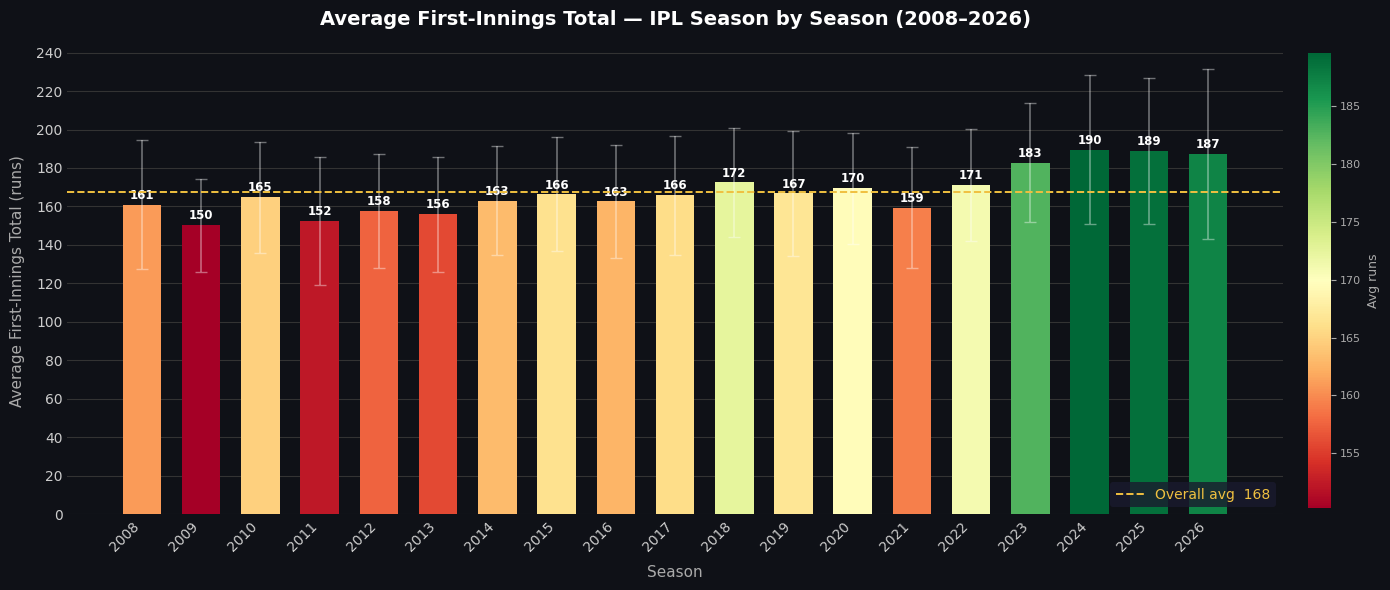

In [6]:
plot_avg_innings_total(1)


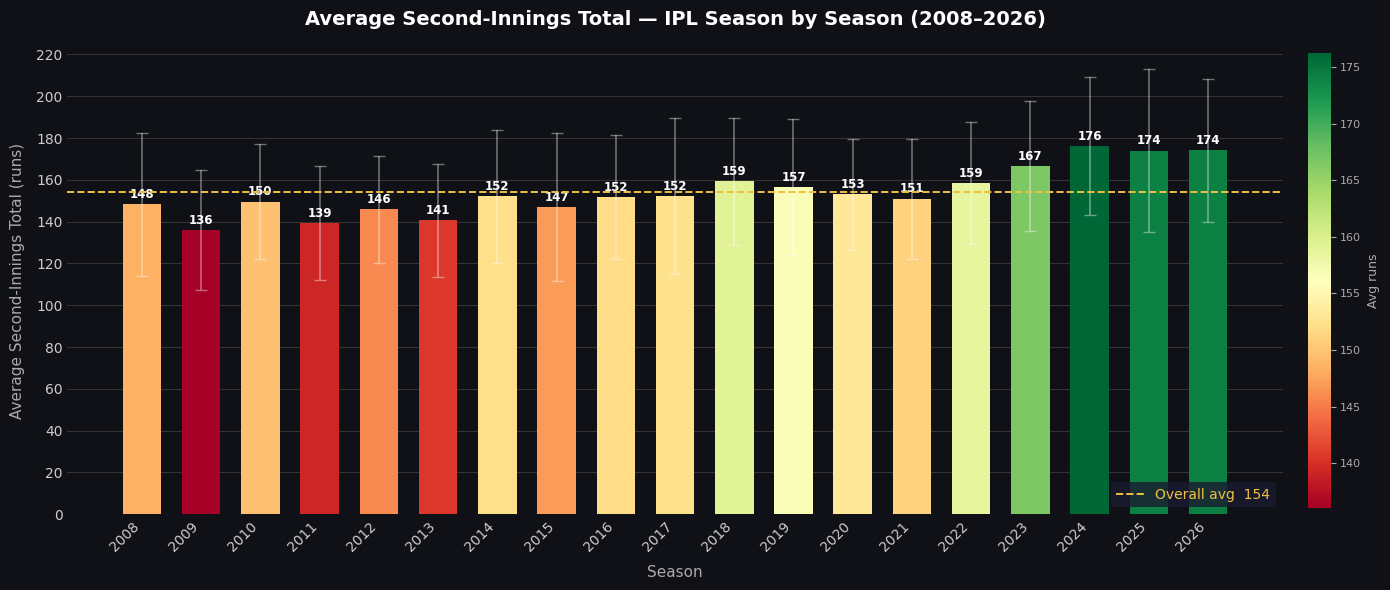

In [7]:
plot_avg_innings_total(2)


In [8]:
def plot_phase_runs(over_start, over_end, phase_name):
    """over_start/over_end are 0-indexed, inclusive."""
    phase = ball_by_ball_data[
        (ball_by_ball_data['innings'].isin([1, 2])) &
        (~ball_by_ball_data['is_super_over']) &
        (ball_by_ball_data['over_number'] >= over_start) &
        (ball_by_ball_data['over_number'] <= over_end)
    ]
    agg = (
        phase.groupby(['season_id', 'innings', 'match_id'])['total_runs'].sum()
        .reset_index()
        .groupby(['season_id', 'innings'])['total_runs'].mean()
        .unstack('innings')
    )
    agg.columns = ['Innings 1', 'Innings 2']
    seasons = agg.index.astype(str)
    x, w = np.arange(len(seasons)), 0.35

    fig, ax = plt.subplots(figsize=(14, 6))
    fig.patch.set_facecolor('#0f1117')
    ax.set_facecolor('#0f1117')

    b1 = ax.bar(x - w/2, agg['Innings 1'], w, label='Innings 1', color='#4c9be8', zorder=3, edgecolor='none')
    b2 = ax.bar(x + w/2, agg['Innings 2'], w, label='Innings 2', color='#e8834c', zorder=3, edgecolor='none')

    for bar in list(b1) + list(b2):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.4,
                f'{bar.get_height():.0f}', ha='center', va='bottom',
                fontsize=7.5, color='white', fontweight='bold')

    ax.set_xticks(x)
    ax.set_xticklabels(seasons, rotation=45, ha='right', color='#cccccc', fontsize=10)
    ax.yaxis.set_major_locator(ticker.MultipleLocator(10))
    ax.tick_params(axis='y', colors='#cccccc', labelsize=10)
    ax.spines[:].set_visible(False)
    ax.tick_params(axis='both', length=0)
    ax.yaxis.grid(True, color='#333333', linewidth=0.8, zorder=0)
    ax.set_axisbelow(True)

    ax.set_xlabel('Season', color='#aaaaaa', fontsize=11, labelpad=8)
    ax.set_ylabel(f'Average {phase_name} Runs', color='#aaaaaa', fontsize=11, labelpad=8)
    ax.set_title(f'Average {phase_name} Runs per Innings — IPL 2008–2026',
                 color='white', fontsize=14, fontweight='bold', pad=16)
    ax.legend(facecolor='#1a1a2e', edgecolor='none', labelcolor='white', fontsize=10, loc='upper left')

    plt.tight_layout()
    plt.show()


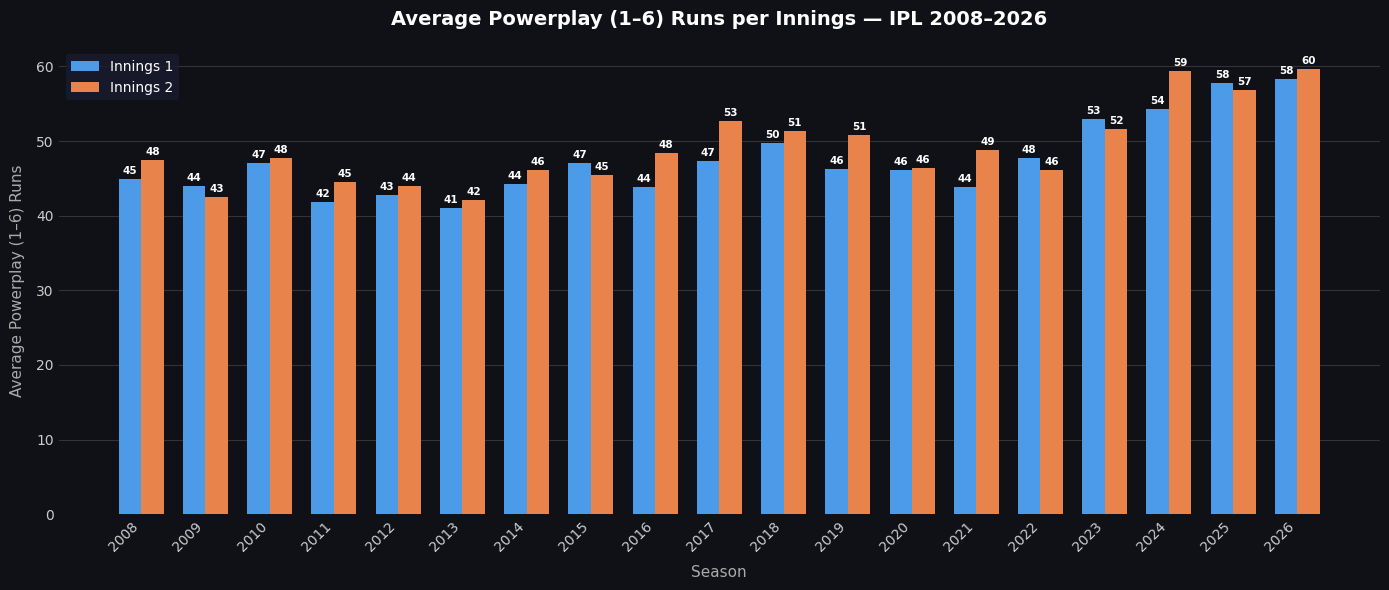

In [9]:
plot_phase_runs(0, 5, 'Powerplay (1–6)')  # overs 1–6


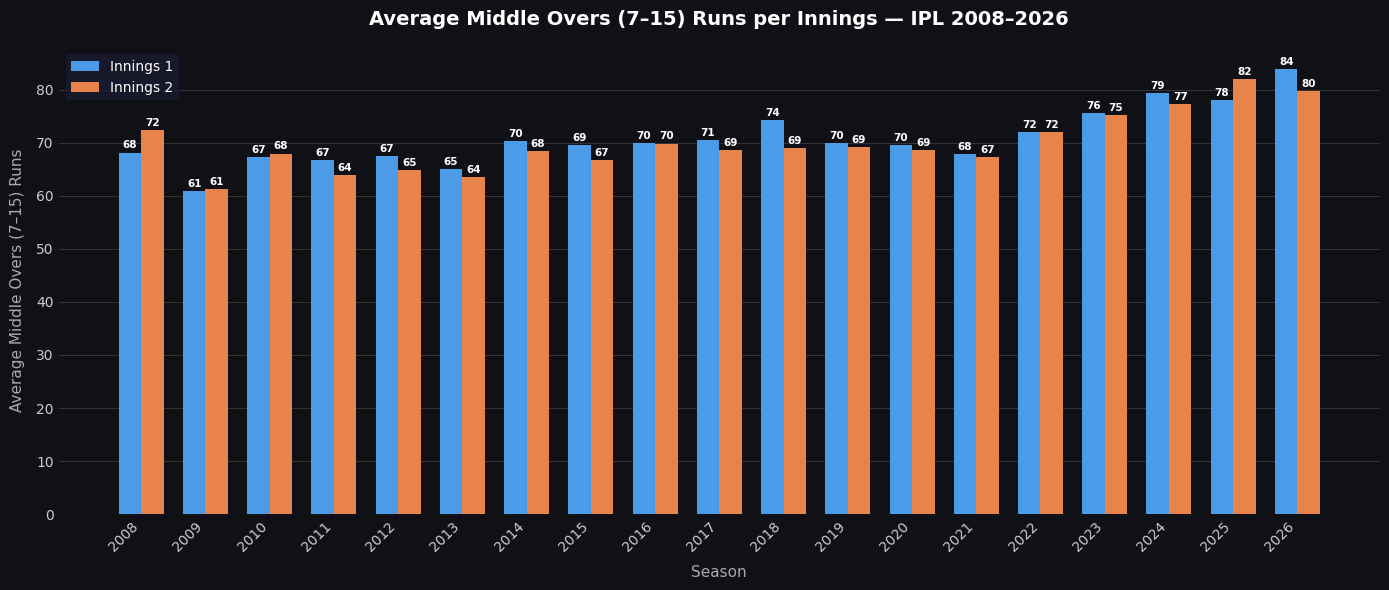

In [10]:
plot_phase_runs(6, 14, 'Middle Overs (7–15)')  # overs 7–15


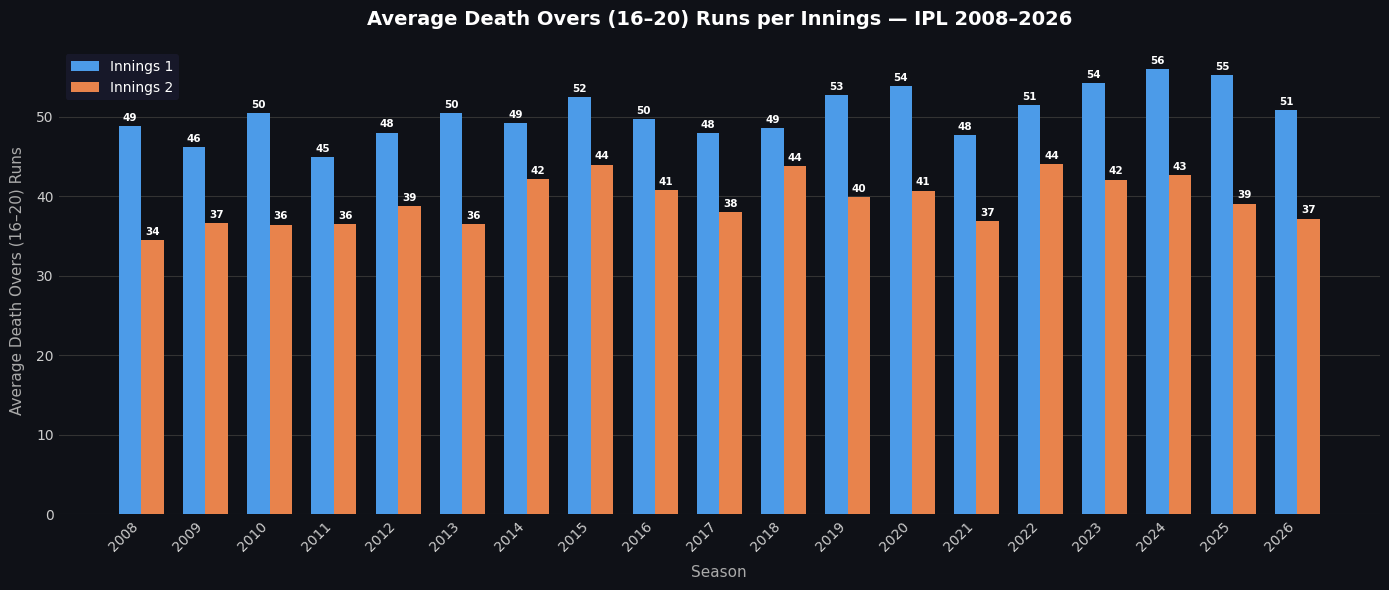

In [11]:
plot_phase_runs(15, 19, 'Death Overs (16–20)')  # overs 16–20
